# Análisis Exploratorio: Variables Categóricas, Hallazgos y Conclusiones

**Proyecto 2. Análisis Exploratorio | LMSYS Chatbot Arena | CC3084 Data Science**

Esta parte continúa el análisis de los notebooks anteriores. La Parte 3 ya mostró que la longitud de
las respuestas se relaciona con la preferencia humana y que la participación de los modelos es muy
desigual, así que acá el foco cambia a **qué modelos ganan**, **cómo cambia su desempeño según la
posición**, **cuándo aparecen empates** y **si hay señales de sesgo entre A y B**.

Las tasas por modelo siempre se acompañan por su número de batallas. Esto es importante porque un
porcentaje calculado con unas pocas observaciones no tiene el mismo respaldo que uno calculado con
miles.

---
## 1. Carga del Dataset Limpio

In [1]:
import sys
from pathlib import Path

ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src import config as cfg
from src import load

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

FIGURAS = ROOT / 'docs' / 'figures'
FIGURAS.mkdir(parents=True, exist_ok=True)

print('Ambiente configurado correctamente.')

Ambiente configurado correctamente.


In [2]:
df = load.load_train_clean()
filas_base, columnas_base = df.shape

ORDEN_RESULTADO = ['model_a gana', 'model_b gana', 'empate']
df['resultado'] = pd.Categorical(
    df['winner'].map(cfg.LABEL_NAMES),
    categories=ORDEN_RESULTADO,
    ordered=True,
)
df['dif_len'] = df['resp_a_len'] - df['resp_b_len']

# Validaciones básicas antes de calcular métricas por modelo.
validacion_ganador = df[cfg.WINNER_COLS].sum(axis=1).eq(1)
modelos = pd.Index(sorted(set(df[cfg.COL_MODEL_A]) | set(df[cfg.COL_MODEL_B])))

print(f'Dataset limpio cargado: {filas_base:,} filas x {columnas_base} columnas')
print('Columnas derivadas para este análisis: resultado y dif_len')
print(f'DataFrame usado en esta parte: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(f'Modelos distintos: {len(modelos)}')
print(f'Filas con exactamente un resultado activo: {validacion_ganador.mean() * 100:.2f}%')
print('Distribución del resultado:')
print((df['resultado'].value_counts(normalize=True).reindex(ORDEN_RESULTADO) * 100).round(2).to_string())


Dataset limpio cargado: 57,406 filas x 17 columnas
Columnas derivadas para este análisis: resultado y dif_len
DataFrame usado en esta parte: 57,406 filas x 19 columnas
Modelos distintos: 64
Filas con exactamente un resultado activo: 100.00%
Distribución del resultado:
resultado
model_a gana    34.94
model_b gana    34.22
empate          30.85


El archivo `train_clean.csv` se carga con **17 columnas**. En esta parte se agregan únicamente dos
variables derivadas para facilitar el análisis: `resultado`, que da una etiqueta legible al ganador,
y `dif_len`, que representa la diferencia de longitud entre las respuestas A y B.

Las tres clases se mantienen casi equilibradas. El empate sigue siendo una clase relevante y no se
elimina: representa una decisión explícita del evaluador y después ayuda a detectar qué modelos o
enfrentamientos son más difíciles de separar.

---
## 2. Win Rate por Modelo

Para cada modelo se cuentan sus apariciones en ambas posiciones. El **win rate** se define como
`victorias / apariciones`, por lo que un empate no cuenta como victoria. También se calcula la tasa de
empate para no esconder ese tercer resultado.

Como la Parte 3 mostró una participación muy desigual, el ranking principal usa únicamente modelos
con **500 o más apariciones**. Los demás permanecen en la tabla completa, pero no se usan para declarar
cuál modelo tiene mejor desempeño observado.

In [3]:
# Resumen por posición A.
stats_a = df.groupby(cfg.COL_MODEL_A).agg(
    apariciones_como_a=(cfg.COL_MODEL_A, 'size'),
    victorias_como_a=(cfg.COL_WIN_A, 'sum'),
    empates_como_a=(cfg.COL_WIN_TIE, 'sum'),
)

# Resumen por posición B.
stats_b = df.groupby(cfg.COL_MODEL_B).agg(
    apariciones_como_b=(cfg.COL_MODEL_B, 'size'),
    victorias_como_b=(cfg.COL_WIN_B, 'sum'),
    empates_como_b=(cfg.COL_WIN_TIE, 'sum'),
)

estadisticas_modelos = stats_a.join(stats_b, how='outer').fillna(0).astype(int)
estadisticas_modelos['apariciones'] = (
    estadisticas_modelos['apariciones_como_a'] + estadisticas_modelos['apariciones_como_b']
)
estadisticas_modelos['victorias'] = (
    estadisticas_modelos['victorias_como_a'] + estadisticas_modelos['victorias_como_b']
)
estadisticas_modelos['empates'] = (
    estadisticas_modelos['empates_como_a'] + estadisticas_modelos['empates_como_b']
)
estadisticas_modelos['derrotas'] = (
    estadisticas_modelos['apariciones']
    - estadisticas_modelos['victorias']
    - estadisticas_modelos['empates']
)

estadisticas_modelos['win_rate'] = (
    estadisticas_modelos['victorias'] / estadisticas_modelos['apariciones']
)
estadisticas_modelos['tie_rate'] = (
    estadisticas_modelos['empates'] / estadisticas_modelos['apariciones']
)
estadisticas_modelos['win_rate_como_a'] = (
    estadisticas_modelos['victorias_como_a'] / estadisticas_modelos['apariciones_como_a']
)
estadisticas_modelos['win_rate_como_b'] = (
    estadisticas_modelos['victorias_como_b'] / estadisticas_modelos['apariciones_como_b']
)

MUESTRA_MODELO = 500
estadisticas_modelos['muestra_suficiente'] = estadisticas_modelos['apariciones'] >= MUESTRA_MODELO

ranking = estadisticas_modelos[estadisticas_modelos['muestra_suficiente']].sort_values(
    'win_rate', ascending=False
)

print(f'Modelos con {MUESTRA_MODELO}+ apariciones: {len(ranking)} de {len(estadisticas_modelos)}')
print('\nTop 12 por win rate con muestra suficiente:')
mostrar = ranking[[
    'apariciones', 'victorias', 'derrotas', 'empates', 'win_rate', 'tie_rate'
]].head(12).copy()
mostrar['win_rate'] = (mostrar['win_rate'] * 100).round(2)
mostrar['tie_rate'] = (mostrar['tie_rate'] * 100).round(2)
mostrar = mostrar.rename(columns={'win_rate': 'win_rate_%', 'tie_rate': 'tie_rate_%'})
mostrar

Modelos con 500+ apariciones: 55 de 64

Top 12 por win rate con muestra suficiente:


,apariciones,victorias,derrotas,empates,win_rate_%,tie_rate_%
model_a,,,,,,
gpt-4-1106-preview,7379,4069,1286,2024,55.14,27.43
gpt-3.5-turbo-0314,1297,711,257,329,54.82,25.37
gpt-4-0125-preview,1158,596,202,360,51.47,31.09
gpt-4-0314,4113,1993,930,1190,48.46,28.93
claude-1,3971,1746,1045,1180,43.97,29.72
claude-instant-1,4124,1642,1279,1203,39.82,29.17
gpt-4-0613,6156,2446,1854,1856,39.73,30.15
qwen1.5-72b-chat,549,215,154,180,39.16,32.79
claude-2.0,2451,956,781,714,39.00,29.13


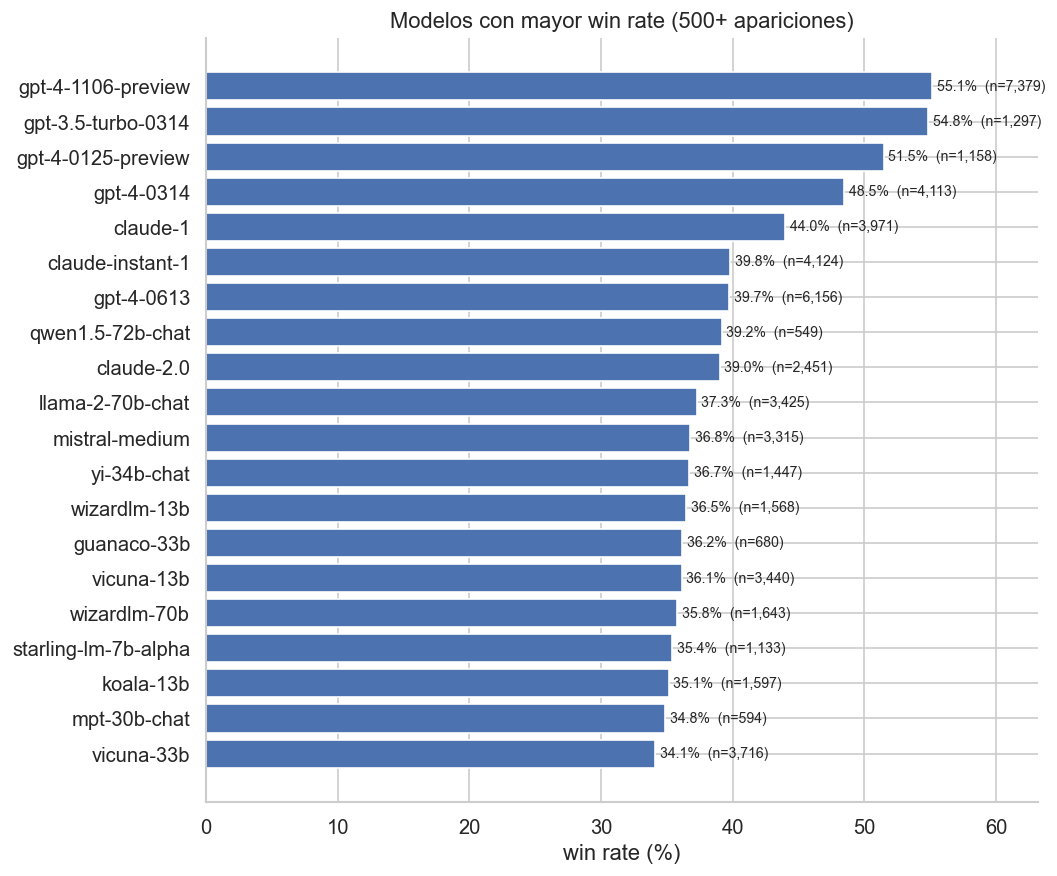

In [4]:
# Se muestran los 20 mejores para mantener el gráfico legible; el ranking se calculó con todos los
# modelos que cumplen el umbral de muestra.
top_grafico = ranking.head(20).sort_values('win_rate')

fig, ax = plt.subplots(figsize=(9, 7.5))
ax.barh(top_grafico.index, top_grafico['win_rate'] * 100, color='#4C72B0')

for y, (modelo, fila) in enumerate(top_grafico.iterrows()):
    ax.text(
        fila['win_rate'] * 100 + 0.35,
        y,
        f'{fila["win_rate"] * 100:.1f}%  (n={fila["apariciones"]:,})',
        va='center',
        fontsize=8.5,
    )

ax.set_xlabel('win rate (%)')
ax.set_ylabel('')
ax.set_title(f'Modelos con mayor win rate ({MUESTRA_MODELO}+ apariciones)')
ax.set_xlim(0, max(60, top_grafico['win_rate'].max() * 100 + 8))
sns.despine()
plt.tight_layout()
plt.savefig(FIGURAS / 'fig_win_rate_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

El ranking con muestra suficiente deja a **gpt-4-1106-preview** en primer lugar: gana **55.14% de
7,379 apariciones**. Muy cerca queda **gpt-3.5-turbo-0314**, con **54.82%**, pero respaldado por
1,297 apariciones. Esta diferencia de tamaño de muestra es la razón por la que no conviene leer el
porcentaje solo.

También aparece un patrón importante: incluso los modelos con mejor win rate tienen muchos empates y
derrotas. No existe un modelo que gane de forma absoluta; el desempeño depende de los rivales y de las
batallas que le tocaron.

---
## 3. Win Rate según Posición A o B

El reparto de apariciones entre A y B ya se revisó en la Parte 3 y quedó cerca de 50/50. Acá se estudia
una pregunta distinta: **si el mismo modelo gana con una frecuencia diferente dependiendo de la
posición en que aparece**.

Para evitar diferencias infladas por muestras pequeñas se exigen al menos **250 apariciones en cada
posición**, que en la práctica deja los mismos 55 modelos de muestra suficiente del análisis anterior.

In [5]:
MIN_POR_POSICION = 250
comparacion_posicion = estadisticas_modelos[
    (estadisticas_modelos['apariciones_como_a'] >= MIN_POR_POSICION)
    & (estadisticas_modelos['apariciones_como_b'] >= MIN_POR_POSICION)
].copy()

comparacion_posicion['diferencia_a_menos_b_pp'] = (
    comparacion_posicion['win_rate_como_a'] - comparacion_posicion['win_rate_como_b']
) * 100
comparacion_posicion['diferencia_abs_pp'] = comparacion_posicion['diferencia_a_menos_b_pp'].abs()

print(f'Modelos comparables en ambas posiciones: {len(comparacion_posicion)}')
print('\nMayores diferencias absolutas entre A y B:')
pos_mostrar = comparacion_posicion.sort_values('diferencia_abs_pp', ascending=False)[[
    'apariciones_como_a', 'win_rate_como_a',
    'apariciones_como_b', 'win_rate_como_b',
    'diferencia_a_menos_b_pp'
]].head(12).copy()
pos_mostrar['win_rate_como_a'] = (pos_mostrar['win_rate_como_a'] * 100).round(2)
pos_mostrar['win_rate_como_b'] = (pos_mostrar['win_rate_como_b'] * 100).round(2)
pos_mostrar['diferencia_a_menos_b_pp'] = pos_mostrar['diferencia_a_menos_b_pp'].round(2)
pos_mostrar

Modelos comparables en ambas posiciones: 55

Mayores diferencias absolutas entre A y B:


,apariciones_como_a,win_rate_como_a,apariciones_como_b,win_rate_como_b,diferencia_a_menos_b_pp
model_a,,,,,
llama2-70b-steerlm-chat,346,30.64,321,22.74,7.89
qwen1.5-72b-chat,276,42.39,273,35.90,6.49
mpt-7b-chat,448,20.31,476,25.42,-5.11
yi-34b-chat,696,34.05,751,39.15,-5.10
gpt-3.5-turbo-0314,643,57.08,654,52.60,4.48
deepseek-llm-67b-chat,430,25.81,365,21.64,4.17
RWKV-4-Raven-14B,587,24.87,569,20.91,3.96
vicuna-7b,762,30.18,826,26.39,3.79
mpt-30b-chat,309,36.57,285,32.98,3.59


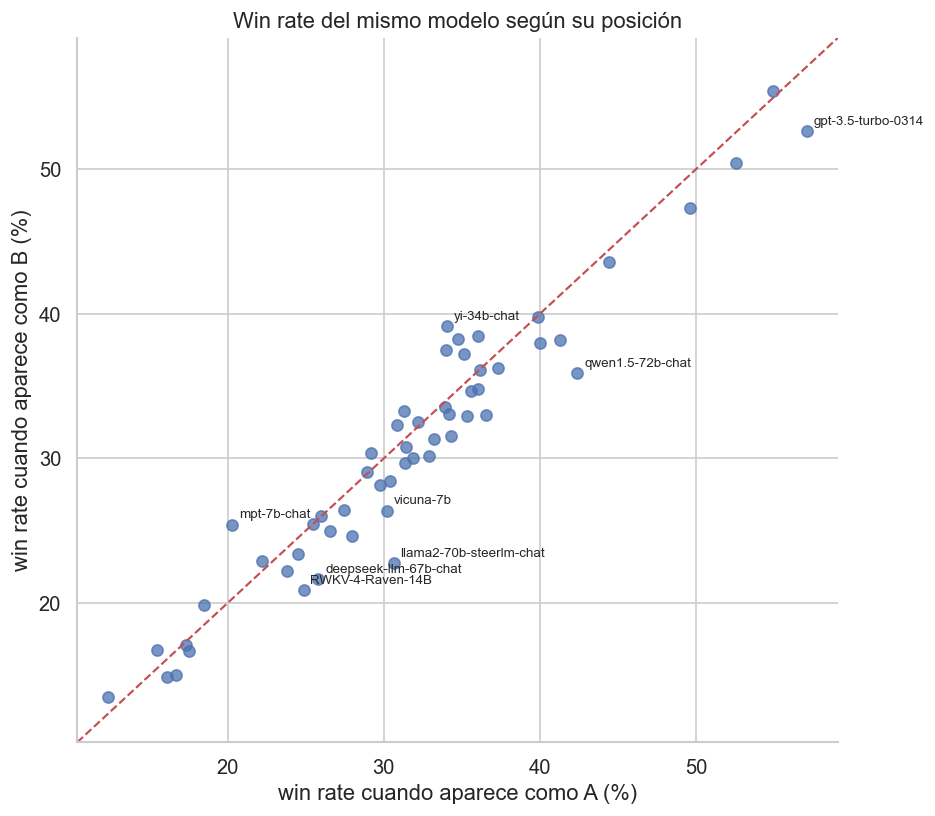

In [6]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(
    comparacion_posicion['win_rate_como_a'] * 100,
    comparacion_posicion['win_rate_como_b'] * 100,
    s=45,
    alpha=0.75,
    color='#4C72B0',
)

lim_inf = min(
    comparacion_posicion['win_rate_como_a'].min(),
    comparacion_posicion['win_rate_como_b'].min(),
) * 100 - 2
lim_sup = max(
    comparacion_posicion['win_rate_como_a'].max(),
    comparacion_posicion['win_rate_como_b'].max(),
) * 100 + 2
ax.plot([lim_inf, lim_sup], [lim_inf, lim_sup], '--', color='#C44E52', linewidth=1.3)

# Se etiquetan solo los modelos con las diferencias más grandes para no saturar el gráfico.
for modelo, fila in comparacion_posicion.nlargest(8, 'diferencia_abs_pp').iterrows():
    ax.annotate(
        modelo,
        (fila['win_rate_como_a'] * 100, fila['win_rate_como_b'] * 100),
        xytext=(4, 4),
        textcoords='offset points',
        fontsize=8,
    )

ax.set_xlim(lim_inf, lim_sup)
ax.set_ylim(lim_inf, lim_sup)
ax.set_xlabel('win rate cuando aparece como A (%)')
ax.set_ylabel('win rate cuando aparece como B (%)')
ax.set_title('Win rate del mismo modelo según su posición')
sns.despine()
plt.tight_layout()
plt.savefig(FIGURAS / 'fig_win_rate_posicion.png', dpi=150, bbox_inches='tight')
plt.show()

La mayoría de los puntos queda cerca de la diagonal, de modo que el desempeño de un modelo suele ser
parecido en A y B. Las diferencias más grandes existen, pero no forman un patrón uniforme a favor de
una sola posición. Por ejemplo, **llama2-70b-steerlm-chat** muestra una brecha de **7.89 puntos
porcentuales a favor de A**, mientras **mpt-7b-chat** presenta una diferencia de **5.11 puntos a favor
de B**.

Esto sugiere que parte de las brechas individuales puede venir de la composición de rivales o del azar
muestral. El análisis global de posición se retoma más adelante para ver si, al juntar todas las
batallas, A o B acumula una ventaja sistemática.

---
## 4. Análisis de Empates por Modelo y por Enfrentamiento

Primero se mide qué modelos terminan en empate con mayor frecuencia. Después se analiza el par de
rivales directamente. El dataset no trae una clasificación confiable de modelos por familia, tamaño o
precio, así que no se inventan categorías externas: el análisis de "contra qué tipo de rival" se hace
con **enfrentamientos concretos entre pares de modelos**.

Para el ranking de pares se requieren al menos **100 enfrentamientos**. Este umbral evita destacar como
principal una tasa extrema calculada con apenas unas decenas de casos.

In [7]:
empates_modelo = estadisticas_modelos[
    estadisticas_modelos['muestra_suficiente']
].sort_values('tie_rate', ascending=False)

print('Modelos con mayor tasa de empate (500+ apariciones):')
emp_mostrar = empates_modelo[['apariciones', 'empates', 'tie_rate']].head(12).copy()
emp_mostrar['tie_rate'] = (emp_mostrar['tie_rate'] * 100).round(2)
emp_mostrar = emp_mostrar.rename(columns={'tie_rate': 'tie_rate_%'})
emp_mostrar

Modelos con mayor tasa de empate (500+ apariciones):


,apariciones,empates,tie_rate_%
model_a,,,
openhermes-2.5-mistral-7b,952,343,36.03
deepseek-llm-67b-chat,795,276,34.72
openchat-3.5,1632,566,34.68
llama-2-7b-chat,1793,619,34.52
chatglm-6b,1259,433,34.39
vicuna-33b,3716,1270,34.18
qwen-14b-chat,1072,363,33.86
stripedhyena-nous-7b,914,308,33.70
gpt-3.5-turbo-0125,859,284,33.06


In [8]:
# Se normaliza el orden de cada par para juntar A-vs-B y B-vs-A en un mismo enfrentamiento.
pares = df[[cfg.COL_MODEL_A, cfg.COL_MODEL_B, cfg.COL_WIN_TIE]].copy()
pares['modelo_1'] = np.where(
    pares[cfg.COL_MODEL_A] <= pares[cfg.COL_MODEL_B],
    pares[cfg.COL_MODEL_A],
    pares[cfg.COL_MODEL_B],
)
pares['modelo_2'] = np.where(
    pares[cfg.COL_MODEL_A] <= pares[cfg.COL_MODEL_B],
    pares[cfg.COL_MODEL_B],
    pares[cfg.COL_MODEL_A],
)

empates_pares = pares.groupby(['modelo_1', 'modelo_2']).agg(
    enfrentamientos=(cfg.COL_WIN_TIE, 'size'),
    empates=(cfg.COL_WIN_TIE, 'sum'),
).reset_index()
empates_pares['tie_rate'] = empates_pares['empates'] / empates_pares['enfrentamientos']

MIN_ENFRENTAMIENTOS_PAR = 100
pares_suficientes = empates_pares[
    empates_pares['enfrentamientos'] >= MIN_ENFRENTAMIENTOS_PAR
].sort_values(['tie_rate', 'enfrentamientos'], ascending=[False, False])

print(f'Pares con {MIN_ENFRENTAMIENTOS_PAR}+ enfrentamientos: {len(pares_suficientes)}')
print('\nPares con mayor tasa de empate:')
pares_mostrar = pares_suficientes.head(12).copy()
pares_mostrar['tie_rate_%'] = (pares_mostrar['tie_rate'] * 100).round(2)
pares_mostrar[['modelo_1', 'modelo_2', 'enfrentamientos', 'empates', 'tie_rate_%']]

Pares con 100+ enfrentamientos: 137

Pares con mayor tasa de empate:


,modelo_1,modelo_2,enfrentamientos,empates,tie_rate_%
693,gpt-4-0125-preview,gpt-4-1106-preview,134,67,50.00
615,gpt-3.5-turbo-0613,gpt-3.5-turbo-1106,268,118,44.03
1234,starling-lm-7b-alpha,zephyr-7b-beta,103,45,43.69
875,llama-2-13b-chat,llama-2-70b-chat,145,63,43.45
1115,openchat-3.5,zephyr-7b-beta,157,67,42.68
720,gpt-4-0314,gpt-4-0613,560,236,42.14
294,claude-2.1,vicuna-33b,103,43,41.75
601,gpt-3.5-turbo-0314,gpt-4-0314,108,45,41.67
876,llama-2-13b-chat,llama-2-7b-chat,123,51,41.46
1257,vicuna-33b,wizardlm-70b,167,69,41.32


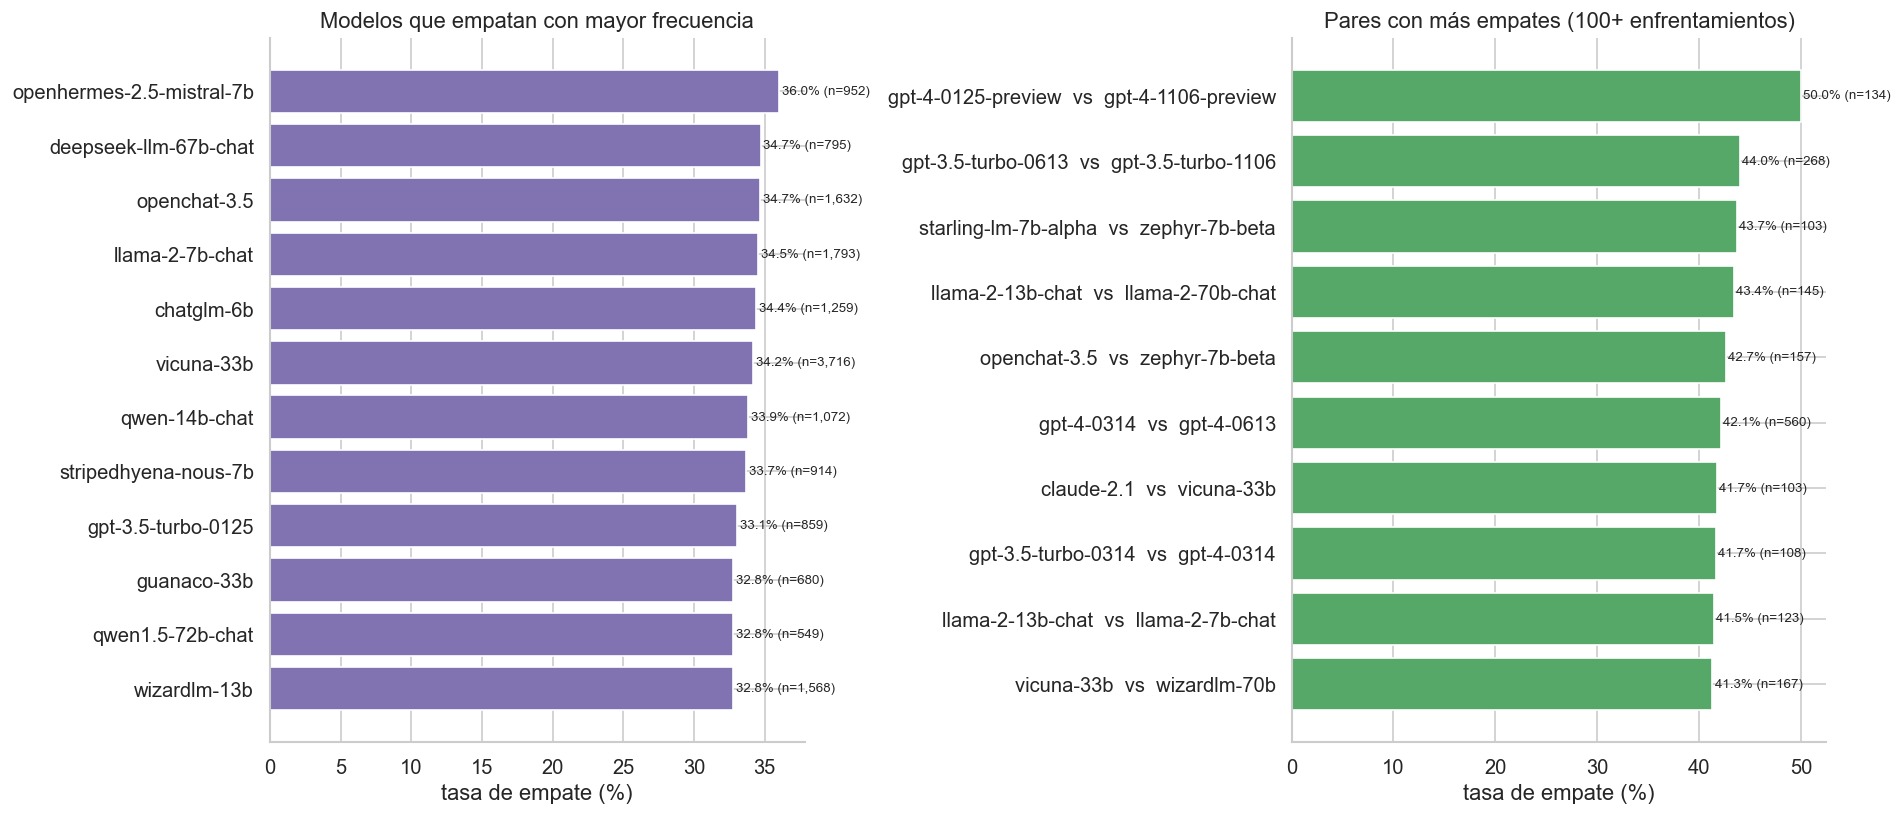

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Panel 1: tasa de empate por modelo.
top_empates_modelo = empates_modelo.head(12).sort_values('tie_rate')
axes[0].barh(top_empates_modelo.index, top_empates_modelo['tie_rate'] * 100, color='#8172B2')
axes[0].set_xlabel('tasa de empate (%)')
axes[0].set_title('Modelos que empatan con mayor frecuencia')
for y, (modelo, fila) in enumerate(top_empates_modelo.iterrows()):
    axes[0].text(
        fila['tie_rate'] * 100 + 0.2,
        y,
        f'{fila["tie_rate"] * 100:.1f}% (n={fila["apariciones"]:,})',
        va='center', fontsize=8,
    )

# Panel 2: tasa de empate en pares con suficiente historial.
top_pares = pares_suficientes.head(10).copy()
top_pares['par'] = top_pares['modelo_1'] + '  vs  ' + top_pares['modelo_2']
top_pares = top_pares.sort_values('tie_rate')
axes[1].barh(top_pares['par'], top_pares['tie_rate'] * 100, color='#55A868')
axes[1].set_xlabel('tasa de empate (%)')
axes[1].set_title(f'Pares con más empates ({MIN_ENFRENTAMIENTOS_PAR}+ enfrentamientos)')
for y, (_, fila) in enumerate(top_pares.iterrows()):
    axes[1].text(
        fila['tie_rate'] * 100 + 0.2,
        y,
        f'{fila["tie_rate"] * 100:.1f}% (n={fila["enfrentamientos"]:,})',
        va='center', fontsize=8,
    )

sns.despine()
plt.tight_layout()
plt.savefig(FIGURAS / 'fig_empates_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

Entre los modelos con al menos 500 apariciones, **openhermes-2.5-mistral-7b** tiene la tasa de empate
más alta: **36.03% en 952 batallas**, alrededor de cinco puntos porcentuales por encima del empate
global del dataset.

Los pares muestran algo todavía más específico. Entre enfrentamientos con 100 o más casos,
**gpt-4-0125-preview vs gpt-4-1106-preview** termina en empate en **50.00% de 134 batallas**. También
destaca **gpt-4-0314 vs gpt-4-0613**, con **42.14% de empates en 560 enfrentamientos**. Esto indica que
el empate depende no solo de un modelo aislado, sino de qué tan comparables resultan los dos rivales
que recibe el evaluador.

---
## 5. Correlaciones entre Variables Numéricas y Resultado

`winner` está codificada como 0, 1 y 2 solo por conveniencia, pero esas cifras representan categorías
nominales. Calcular Pearson directamente contra esa columna impondría un orden artificial. Por eso el
resultado se representa con sus tres indicadores binarios originales: `winner_model_a`,
`winner_model_b` y `winner_tie`.

La Parte 3 ya verificó que caracteres y palabras son casi equivalentes. Para no duplicar información en
el heatmap se conservan las longitudes en caracteres, `n_turns` y `dif_len`, que resume cuánto más
larga fue A que B.

In [10]:
COLS_CORR = [
    'prompt_len', 'resp_a_len', 'resp_b_len', 'dif_len', 'n_turns',
    cfg.COL_WIN_A, cfg.COL_WIN_B, cfg.COL_WIN_TIE,
]
correlaciones = df[COLS_CORR].corr()

print('Correlaciones de las variables numéricas con cada resultado:')
correlaciones.loc[
    ['prompt_len', 'resp_a_len', 'resp_b_len', 'dif_len', 'n_turns'],
    [cfg.COL_WIN_A, cfg.COL_WIN_B, cfg.COL_WIN_TIE],
].round(3)

Correlaciones de las variables numéricas con cada resultado:


,winner_model_a,winner_model_b,winner_tie
prompt_len,-0.003,-0.008,0.011
resp_a_len,0.092,-0.042,-0.052
resp_b_len,-0.035,0.086,-0.052
dif_len,0.177,-0.179,0.001
n_turns,0.009,0.009,-0.018


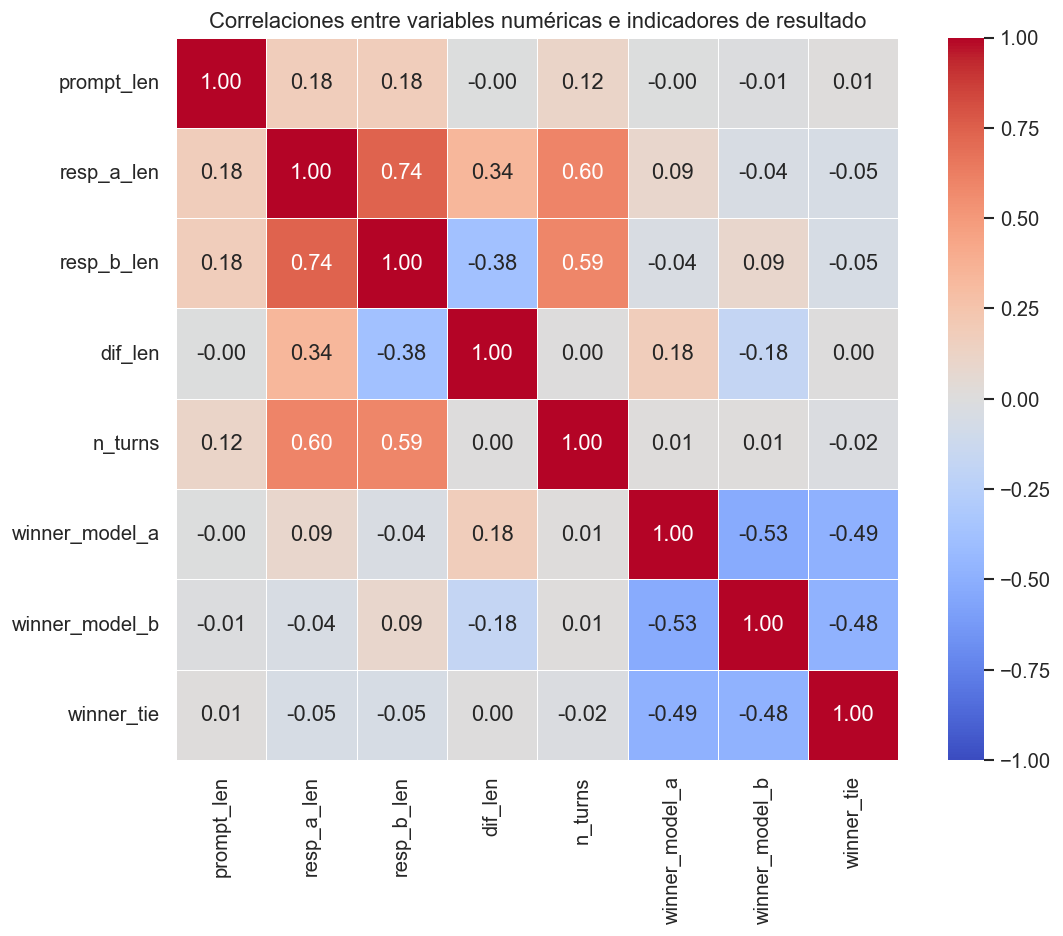

In [11]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    correlaciones,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=.5,
    ax=ax,
)
ax.set_title('Correlaciones entre variables numéricas e indicadores de resultado')
plt.tight_layout()
plt.savefig(FIGURAS / 'fig_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

Las correlaciones con el resultado son bajas en magnitud. La señal más clara vuelve a aparecer en la
diferencia de longitud: `dif_len` correlaciona **+0.177 con victoria de A** y **-0.179 con victoria de
B**. Esto es coherente con el sesgo por verbosidad medido en la Parte 3, pero sigue lejos de una
relación determinante.

Las correlaciones entre `winner_model_a`, `winner_model_b` y `winner_tie` deben interpretarse con
cuidado: son indicadores mutuamente excluyentes de una misma variable categórica, así que parte de su
relación negativa es mecánica y no representa un efecto causal.

La longitud del prompt y el número de turnos tienen correlaciones cercanas a cero con quién gana. El
EDA no encuentra una variable numérica simple que explique por sí sola la preferencia humana; para el
modelado hará falta combinar características del texto, identidad de los modelos y composición del
enfrentamiento.

---
## 6. Longitud de A contra Longitud de B según el Resultado

Este gráfico no vuelve a calcular si "la respuesta más larga gana", porque eso ya quedó cuantificado en
la Parte 3. Su objetivo es mostrar cómo se distribuyen conjuntamente las longitudes de A y B y dónde se
ubican las tres clases de resultado.

Para que decenas de miles de puntos no tapen el patrón se usa una muestra aleatoria reproducible de
12,000 batallas. Los límites se fijan en el percentil 99 de cada eje **solo para visualización**; los
cálculos de este notebook siempre usan el dataset completo.

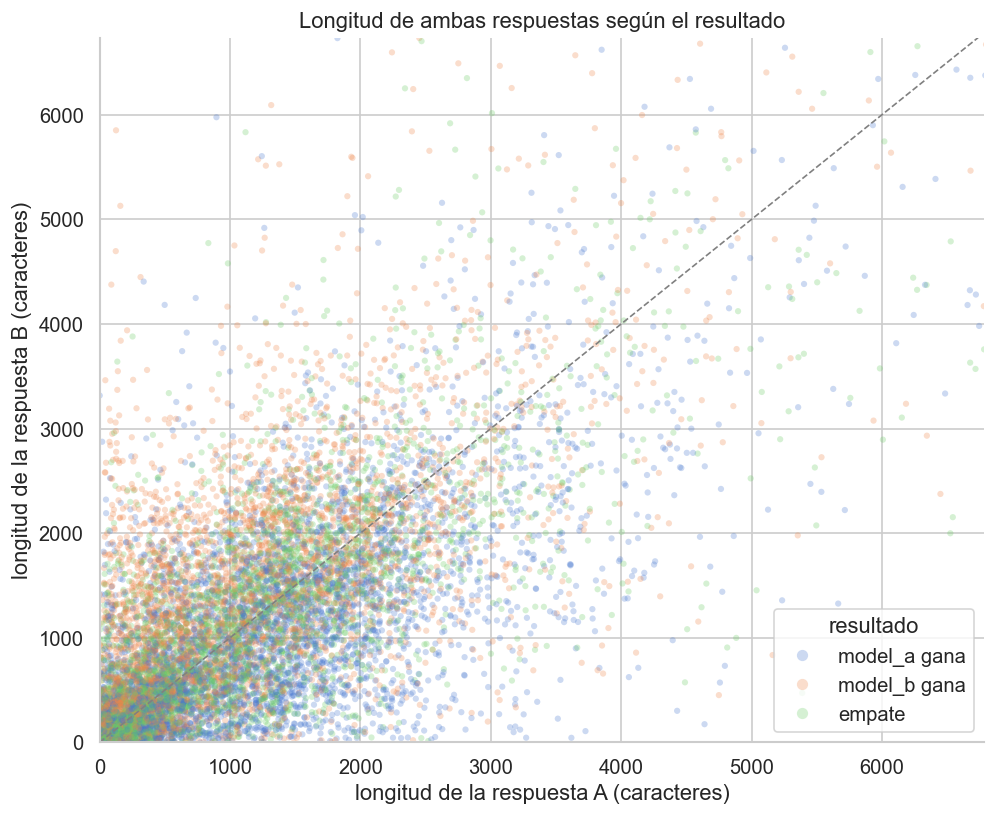

In [12]:
N_SCATTER = min(12_000, len(df))
muestra_scatter = df.sample(N_SCATTER, random_state=42)
lim_a = df['resp_a_len'].quantile(.99)
lim_b = df['resp_b_len'].quantile(.99)

fig, ax = plt.subplots(figsize=(8.5, 7))
sns.scatterplot(
    data=muestra_scatter,
    x='resp_a_len',
    y='resp_b_len',
    hue='resultado',
    hue_order=ORDEN_RESULTADO,
    alpha=.28,
    s=14,
    linewidth=0,
    ax=ax,
)
ax.plot([0, min(lim_a, lim_b)], [0, min(lim_a, lim_b)], '--', color='gray', linewidth=1)
ax.set_xlim(0, lim_a)
ax.set_ylim(0, lim_b)
ax.set_xlabel('longitud de la respuesta A (caracteres)')
ax.set_ylabel('longitud de la respuesta B (caracteres)')
ax.set_title('Longitud de ambas respuestas según el resultado')
ax.legend(title='resultado', markerscale=1.8)
sns.despine()
plt.tight_layout()
plt.savefig(FIGURAS / 'fig_scatter_longitudes_resultado.png', dpi=150, bbox_inches='tight')
plt.show()

La diagonal representa batallas donde ambas respuestas tienen una extensión parecida. Los empates se
mezclan bastante alrededor de esa zona, mientras las victorias de A y B se desplazan en las direcciones
esperadas cuando una respuesta se vuelve más larga que la otra. Aun así hay mucho solapamiento entre
colores, otra señal de que la longitud ayuda pero no alcanza para reconstruir el voto.

---
## 7. Sesgo Global de Posición

Como cada batalla siempre tiene un modelo en A y otro en B, el control importante no es contar cuántas
posiciones A y B existen globalmente, sino revisar dos cosas juntas:

1. La Parte 3 encontró que, para los modelos con suficiente muestra, el reparto individual entre A y B
   se mantiene cerca de 50/50.
2. Acá se compara cuántas **victorias** obtiene cada posición.

Para separar el efecto del empate también se calcula la proporción A/B únicamente entre batallas con
ganador definido.

In [13]:
victorias_a = int(df[cfg.COL_WIN_A].sum())
victorias_b = int(df[cfg.COL_WIN_B].sum())
empates = int(df[cfg.COL_WIN_TIE].sum())
decisivas = victorias_a + victorias_b

pct_a_total = victorias_a / len(df) * 100
pct_b_total = victorias_b / len(df) * 100
pct_empate = empates / len(df) * 100
pct_a_decisivas = victorias_a / decisivas * 100
pct_b_decisivas = victorias_b / decisivas * 100
diferencia_decisivas = pct_a_decisivas - pct_b_decisivas

# Control del reparto por modelo, equivalente al chequeo de la Parte 3.
participacion_pos = pd.DataFrame({
    'como_a': df[cfg.COL_MODEL_A].value_counts(),
    'como_b': df[cfg.COL_MODEL_B].value_counts(),
}).fillna(0)
participacion_pos['apariciones'] = participacion_pos['como_a'] + participacion_pos['como_b']
participacion_pos['pct_como_a'] = participacion_pos['como_a'] / participacion_pos['apariciones'] * 100
frecuentes_pos = participacion_pos[participacion_pos['apariciones'] >= MUESTRA_MODELO]

print(f'Victorias de A: {victorias_a:,} ({pct_a_total:.2f}% del total)')
print(f'Victorias de B: {victorias_b:,} ({pct_b_total:.2f}% del total)')
print(f'Empates:        {empates:,} ({pct_empate:.2f}% del total)')
print()
print(f'Entre las {decisivas:,} batallas decisivas:')
print(f'  A gana: {pct_a_decisivas:.2f}%')
print(f'  B gana: {pct_b_decisivas:.2f}%')
print(f'  Diferencia A - B: {diferencia_decisivas:+.2f} puntos porcentuales')
print()
print(f'Control de asignación en modelos con {MUESTRA_MODELO}+ apariciones:')
print(f'  Promedio de apariciones como A: {frecuentes_pos["pct_como_a"].mean():.2f}%')
print(f'  Desviación absoluta media respecto a 50%: {(frecuentes_pos["pct_como_a"] - 50).abs().mean():.2f} pp')
print(f'  Mayor desviación observada respecto a 50%: {(frecuentes_pos["pct_como_a"] - 50).abs().max():.2f} pp')

Victorias de A: 20,055 (34.94% del total)
Victorias de B: 19,643 (34.22% del total)
Empates:        17,708 (30.85% del total)

Entre las 39,698 batallas decisivas:
  A gana: 50.52%
  B gana: 49.48%
  Diferencia A - B: +1.04 puntos porcentuales

Control de asignación en modelos con 500+ apariciones:
  Promedio de apariciones como A: 50.00%
  Desviación absoluta media respecto a 50%: 1.02 pp
  Mayor desviación observada respecto a 50%: 4.09 pp


La posición A gana **50.52% de las batallas decisivas** y B gana **49.48%**, una diferencia de apenas
**1.04 puntos porcentuales**. Al mismo tiempo, los modelos con 500 o más apariciones están asignados a
A un promedio de **50.00%** de las veces y su desviación absoluta media respecto a 50% es de solo
**1.02 puntos porcentuales**.

Descriptivamente hay una pequeña ventaja global de A en las victorias, pero su magnitud es baja. Con
este EDA no corresponde afirmar que existe un sesgo causal o estadísticamente demostrado del
evaluador. Sí conviene conservar la posición como variable de control en una etapa de modelado y
verificar si la diferencia se mantiene después de ajustar por modelo y rival.

---
## 8. Hallazgos

**1. gpt-4-1106-preview tiene el mejor desempeño observado entre los modelos con muestra suficiente.**
Registra **55.14% de victorias en 7,379 apariciones** y una tasa de empate de **27.43%**. Además, su win
rate es muy estable entre posiciones: **54.89% como A y 55.39% como B**. Esa combinación de tasa,
tamaño de muestra y estabilidad lo vuelve más convincente que un porcentaje alto respaldado por pocas
batallas.

**2. La posición puede mover la tasa de victoria de un modelo particular, pero no siempre en la misma
dirección.** `llama2-70b-steerlm-chat` gana **30.64% como A y 22.74% como B**, una brecha de
**7.89 puntos porcentuales** a favor de A. En cambio, `mpt-7b-chat` gana **20.31% como A y 25.42% como
B**, una diferencia de **5.11 puntos a favor de B**. Esto hace difícil atribuir las brechas individuales
a un único sesgo global de posición.

**3. Los empates dependen del modelo y, todavía más, del rival que enfrenta.**
`openhermes-2.5-mistral-7b` empata **36.03% de sus 952 apariciones**, por encima del **30.85%** global.
En pares con al menos 100 enfrentamientos, `gpt-4-0125-preview` contra `gpt-4-1106-preview` llega a
**50.00% de empates en 134 batallas**.

**4. La diferencia de longitud tiene relación con el voto, pero la correlación es moderada-baja.**
`dif_len` presenta correlación de **+0.177 con victoria de A** y **-0.179 con victoria de B**. El signo
es consistente con la preferencia por respuestas más extensas encontrada en la Parte 3, pero la
magnitud confirma que la verbosidad no explica por sí sola la elección humana.

**5. No se observa una señal numérica fuerte en la longitud del prompt ni en el número de turnos para
predecir qué lado gana.** Sus correlaciones con los indicadores de victoria quedan muy cerca de cero.
La preferencia parece depender más de las respuestas y de los modelos enfrentados que de una medida
simple del tamaño de la pregunta o de la duración de la conversación.

**6. La ventaja global de posición A es pequeña.** Entre las batallas con ganador, A obtiene
**50.52%** de las victorias y B **49.48%**, una diferencia de **1.04 puntos porcentuales**. Como la
asignación de modelos entre A y B está muy cerca de 50/50, vale la pena controlar la posición en el
modelado, pero este EDA no da base para llamarla un sesgo fuerte.

---
## 9. Conclusiones y Siguientes Pasos

El análisis exploratorio muestra que la preferencia humana no puede resumirse con una sola variable.
La **identidad del modelo**, el **rival contra el que compite** y ciertas características de la
respuesta, como la diferencia de longitud, están relacionadas con el resultado. La longitud aporta
señal, pero el solapamiento entre victorias y empates deja claro que hace falta representar contenido y
calidad de la respuesta, no solo su tamaño.

Para una etapa posterior de modelado conviene conservar las variables de longitud, `n_turns`, la
posición A/B y la identidad de ambos modelos. También sería útil construir características del texto y
usar un método que ajuste por la **fuerza del rival**, porque el win rate bruto mezcla desempeño con el
calendario de enfrentamientos. Un modelo de ranking por pares, como Bradley-Terry, o un clasificador
multiclase que mantenga el empate como tercera clase permitiría controlar mejor esos factores.

Los empates no deberían eliminarse. Son casi un tercio del dataset y aparecen con distinta frecuencia
según el modelo y el par de rivales. Quitarlos cambiaría el problema y escondería precisamente los
casos donde el evaluador no encuentra una diferencia clara entre dos respuestas.

Sobre la posición, A muestra una ventaja descriptiva de alrededor de un punto porcentual entre las
batallas decisivas. Es pequeña frente a las diferencias observadas entre modelos y no basta para afirmar
causalidad. En un modelo posterior se puede incluir la posición como control y comprobar si el efecto
permanece al ajustar por modelo, rival y características de la respuesta.

### Implicación de negocio

Si hubiera que elegir un candidato **solo con la evidencia de este EDA**, `gpt-4-1106-preview` es la
opción observacional más sólida: combina el mayor win rate entre modelos con 500+ apariciones,
7,379 observaciones, una tasa de empate relativamente baja y comportamiento estable entre A y B. Esto
no significa que sea automáticamente el mejor modelo para producción. El dataset no controla de forma
completa la dificultad de los rivales y tampoco incluye costo, latencia, seguridad ni desempeño por
tipo de tarea.

La decisión de producción debería confirmar el ranking con un análisis ajustado por rival y después
cruzarlo con métricas operativas. Así se evita escoger un modelo únicamente porque tuvo un calendario
más favorable, escribió más o acumuló muchas batallas en un subconjunto particular de usuarios.